### Реализуем моедль семантической близости слов

In [1]:
from collections import defaultdict, Counter
from functools import lru_cache
from typing import List, Iterable, Dict, Callable
from abc import abstractmethod
import pandas as pd
import scipy
import numpy as np
from scipy import sparse as sp
from tqdm.auto import tqdm
from scipy.sparse.linalg import svds

Данные для выполнения задания: https://drive.google.com/file/d/1lC6p2PicqrM2VChjXzsavgpCde66Wfhe/view

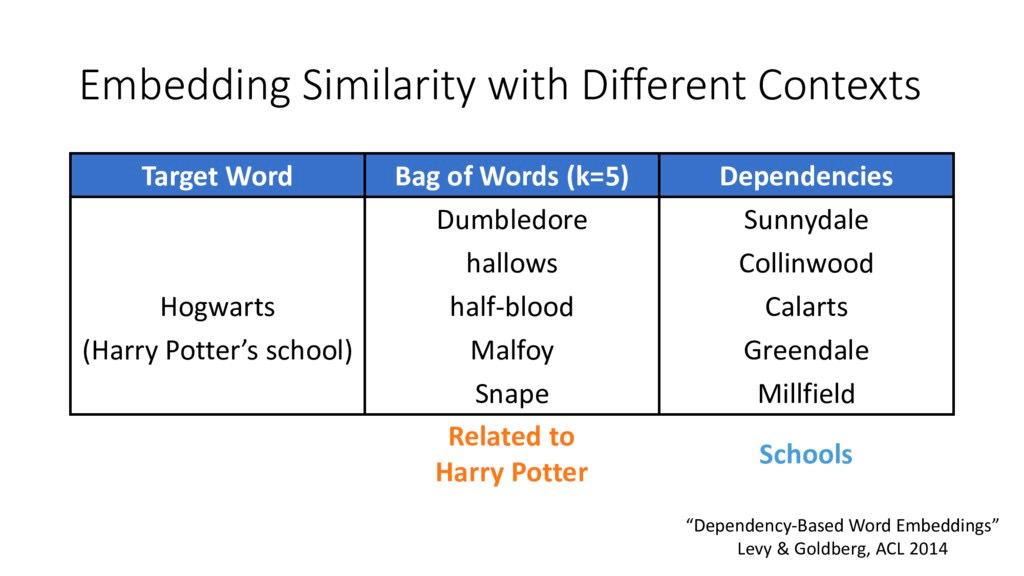

In [2]:
data = pd.read_csv("./vectors/gold.csv")

In [3]:
golden = [ans for ans in data["sim"]]
examples = [(w1, w2) for w1, w2 in zip(data["word1"], data["word2"])]
assert len(golden) == len(examples)

In [4]:
class Sentences(object):
    """ Итератор по строкам заданных файлов, не загружающий их полностью в RAM """

    def __init__(self, filenames: Iterable[str]):
        self.filenames: Iterable = filenames

    def __iter__(self):
        for filename in self.filenames:
            for line in open(filename, "r+", encoding="utf-8"):
                yield line.strip().replace("ё", "е").split(" ")

In [5]:
class EmbeddingModel:

    @abstractmethod
    def get(word: str) -> np.array:
        raise NotImplementedError

### Реализуйте PPMI подход [3 балла]

In [6]:
class PPMIEmbeddings(EmbeddingModel):
    """
        Класс, строящий векторные представления для каждого из интересующих нас термов
        по набору предобработанных текстов, а также вычисляющий меру их сходства
        на основе косинусного расстояния, и задающий порог для него, говорящий, похожи два данных
        терма или нет (`are_similar`).
    """

    def __init__(self,
                 n_features: int = 400,
                 threshold: float = 0.2,
                 window_half_size: int = 2,
                 min_df: int = 5,
                 max_df: int = 1000000):
        """
            @param: threshold Порог для отсечения по косинусному расстоянию
            @param: window_half_size Половинка "окна", то есть макс. расстояние от центра окна
            @param: min_df Если частота терма ниже этого порога -- выбрасываем (not implemented)
            @param: max_df Если частота терма выше этого порога -- выбрасываем (not implemented)
        """
        self.n_features = n_features
        self.th, self.whs = threshold, window_half_size
        self.ppmi, self.counts, self.ppmi_dense = None, None, None
        self.min_df, self.max_df = min_df, max_df

        # список термов
        self.id2token: List[str] = []
        # словарь индексов термов
        self.token2id: Dict[str, int] = {}

    @lru_cache(maxsize=100000000)
    def _idx(self, token: str):
        """ Кэширующий метод, получающий индекс терма """

        if token not in self.token2id:
            curr_idx = len(self.id2token)
            self.token2id[token] = curr_idx
            self.id2token.append(token)
        else:
            curr_idx = self.token2id[token]
        return curr_idx

    def _reset(self):
        """ Сброс всего 'выученного' (но не гиперпараметров) """
        self.ppmi, self.counts, self.token2id, self.id2token = None, None, {}, []

    def _coocurance_count(self, text_reader, for_exclusion):
        # счётчик, номер строки, номер столбца
        values, fromm, too = [], [], []

        # общее число -- может пригодиться для нормализации и др.
        total_counts = defaultdict(lambda: 0)

        for sentence in tqdm(text_reader(), "sentences"):

            filtered_sentence = [word for word in sentence if word not in for_exclusion]

            # проходим центром по предложению
            for c in range(len(filtered_sentence)):
                center_token = filtered_sentence[c]
                center_idx = self._idx(center_token)
                total_counts[center_idx] += 1

                # проходим вдоль окна
                for idx in range(max(0, c - self.whs), min(len(filtered_sentence), c + self.whs)):
                    if idx == c:
                        continue
                    token = filtered_sentence[idx]
                    token_idx = self._idx(token)
                    values.append(1)
                    fromm.append(center_idx)
                    too.append(token_idx)

        coo = sp.coo_matrix((values, (fromm, too)))
        coo.sum_duplicates()
        return coo, total_counts

    def _pmi_calculation(self, coo):
        nonzero_size = len(coo.nonzero()[0])
        print(f"Sparsity: %.2f nonzero values: a total of %d." % \
              (100 * nonzero_size / coo.shape[0] / coo.shape[1], nonzero_size))

        values = []

        total_counts_sum = self.counts.sum()
        # coo *= total_counts_sum

        for i, j, v in tqdm(zip(coo.row, coo.col, coo.data), "computing PPMI", total=nonzero_size):
            count_i = self.counts[0, i]
            count_j = self.counts[0, j]

            if count_i == 0 or count_j == 0:
                pmi_val = 0
            else:
                pmi_val = np.log((v * total_counts_sum) / (count_i * count_j) + 1e-10)
            values.append(max(pmi_val, 0))

        # преобразовываем в разреженную матрицу с эффективной укладкой по строкам
        self.ppmi = sp.csr_matrix(sp.coo_matrix((values, (coo.row, coo.col))))
        self.ppmi_dense = self.ppmi.toarray()


    def fit(self, text_reader: Callable):
        """
            Построение матрицы с векторными представлениями
            на основе поданных предобработанных предложений.
            Базовый выданный код -- не самый эффективный,
            для удобства проведения инкрементальных улучшений
            рекомендуется ускорить.
            YOUR CODE HERE, так сказать.
        """

        self._reset()
        word_counter = Counter()

        for_exclusion = []
        
        for sentence in tqdm(text_reader(), "count words"):
            word_counter.update(sentence)
        
        for key in tqdm(word_counter.keys(), "bad guys"):
            # check if the word is 'bad'
            if word_counter[key] < self.min_df or word_counter[key] > self.max_df:
                for_exclusion.append(key)

        for_exclusion = set(for_exclusion)
        print("For exclusion, terms:", len(for_exclusion))

        coo, total_counts = self._coocurance_count(text_reader, for_exclusion)

        # строим разреженную матрицу на основе полученных троек

        # укладываем общую встречаемость термов в массив
        self.counts = sp.csr_matrix(np.array([total_counts[i] for i in range(len(self.id2token))]))

        print(f"A total of {len(self.id2token)} terms.")
        print(f"Matrix of size {coo.shape} was built.")

        self._pmi_calculation(coo)

        return None

    def get(self, word: str) -> np.array:
        word = word.replace("ё", "е")
        token_idx = self.token2id.get(word)
        if token_idx is None:
            raise ValueError(f"The word '{word}' is not in the vocabulary.")
        if self.ppmi_dense is not None:
            return self.ppmi_dense[token_idx]
        else:
            return self.ppmi[token_idx].toarray().flatten()

In [7]:
sentences = lambda: Sentences(filenames=["./vectors/rus_araneum_maxicum-1M_lines.txt"])
whs, th, mindf = 3, 0.4, 10
embs = PPMIEmbeddings(window_half_size=whs, threshold=th, min_df=mindf)
embs.fit(sentences)

count words: 0it [00:00, ?it/s]

bad guys:   0%|          | 0/204858 [00:00<?, ?it/s]

For exclusion, terms: 163163


sentences: 0it [00:00, ?it/s]

A total of 41695 terms.
Matrix of size (41695, 41695) was built.
Sparsity: 0.89 nonzero values: a total of 15530761.


computing PPMI:   0%|          | 0/15530761 [00:00<?, ?it/s]

### Реализуйте класс, вычисляющий близость для семантических векторов [1 балл]

In [6]:
from scipy.spatial import distance
class SimilarityModel:
    def __init__(self,
                model: EmbeddingModel,
                threshold: float):
        self._th = threshold
        self._model = model
        self._skipped = 0

    def score(self, word1: np.array, word2: np.array) -> float:
        norm1 = np.linalg.norm(word1)
        norm2 = np.linalg.norm(word2)
        
        if norm1 == 0 or norm2 == 0:
            return 1.0
        return distance.cosine(word1, word2)

    def are_similar(self, word1: str, word2: str) -> bool: 
        """В данной функции необходимо проверить, не превосходит ли получившаяся оценка близости установленного ранее порога"""
        try:
            wv1, wv2 = self._model.get(word1 + "_NOUN"), self._model.get(word2 + "_NOUN")
            return self.score(wv1, wv2) >= self._th
        except:
            self._skipped += 1
            return False

In [7]:
from sklearn.metrics import average_precision_score
def calculate_metric(similarity_model: SimilarityModel):
    predict = [int(similarity_model.are_similar(w1, w2)) for w1, w2 in examples]
    return average_precision_score(golden, predict)

In [10]:
# for debug (using 100k data)
print(calculate_metric(SimilarityModel(model=embs, threshold=0.4)))
assert calculate_metric(SimilarityModel(model=embs, threshold=0.4)) >= 0.38

0.4792413234745718


### Каждый пройденный assert даёт 0.5 балла, в итоге за выполненный пункт: [2 балла]

In [11]:
assert calculate_metric(SimilarityModel(model=embs, threshold=0.4)) >= 0.385
print("Slytherin gets 3 points")
assert calculate_metric(SimilarityModel(model=embs, threshold=0.5)) >= 0.46
print("Hufflepuff gets 2 points")
assert calculate_metric(SimilarityModel(model=embs, threshold=0.5)) >= 0.47
print("Ravenclaw gets 1 points")
assert calculate_metric(SimilarityModel(model=embs, threshold=0.5)) >= 0.51
print("Gryffindor gets 2 points")

Slytherin gets 3 points
Hufflepuff gets 2 points
Ravenclaw gets 1 points


AssertionError: 

### Добавьте в предыдущий подход SVD-разложение из numpy/sklearn [2 балла]

In [9]:
from sklearn.decomposition import TruncatedSVD

class SVDPPMIEmbeddings(PPMIEmbeddings):

    def _svd_reduction(self):
        if self.ppmi is None:
            raise ValueError("PPMI matrix is not computed. Call fit() first.")
        svd = TruncatedSVD(n_components=self.n_features, random_state=42)
        self.ppmi_dense = svd.fit_transform(self.ppmi.toarray())
        print(f"SVD completed. Sum explained variance: {svd.explained_variance_ratio_.sum():.4f}")

    def fit(self, text_reader: Callable):
        super().fit(text_reader)
        self._svd_reduction()

In [12]:
sentences = lambda: Sentences(filenames=["./vectors/rus_araneum_maxicum-1M_lines.txt"])
whs, th, mindf = 3, 0.4, 10
embs = SVDPPMIEmbeddings(n_features=1000, window_half_size=whs, threshold=th, min_df=mindf)
embs.fit(sentences)

count words: 0it [00:00, ?it/s]

bad guys:   0%|          | 0/204858 [00:00<?, ?it/s]

For exclusion, terms: 163163


sentences: 0it [00:00, ?it/s]

A total of 41695 terms.
Matrix of size (41695, 41695) was built.
Sparsity: 0.89 nonzero values: a total of 15530761.


computing PPMI:   0%|          | 0/15530761 [00:00<?, ?it/s]

SVD completed. Sum explained variance: 0.2694


In [14]:
print(calculate_metric(SimilarityModel(model=embs, threshold=0.4)))
assert calculate_metric(SimilarityModel(model=embs, threshold=0.4)) >= 0.385
print("Slytherin gets 3 points")

0.4741835684869051
Slytherin gets 3 points


### Реализуйте метод на основе predictive подхода [1 балл]

In [14]:
from gensim.models import Word2Vec
import logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

class PredectiveEmbeddingModel(EmbeddingModel):
    
    def __init__(self,
                 vector_size: int = 400,
                 window: int = 5,
                 min_count: int = 1,
                 sg: int = 1,
                 negative: int = 10,
                 epochs: int = 30):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.negative = negative
        self.epochs = epochs
        self.model = None

    def fit(self, text_reader: Callable):
        sentences = list(text_reader())
        self.model = Word2Vec(
                        sentences,
                        vector_size=self.vector_size,
                        window=self.window,
                        min_count=self.min_count,
                        sg=self.sg,
                        negative=self.negative,
                        epochs=self.epochs,
                        compute_loss=True,
                        seed=42,
                        workers=10
                    )

        self.model.wv.fill_norms()

    def get(self, word: str) -> np.array:
        """
        Возвращает вектор для заданного слова.
        Если слово отсутствует в словаре модели, генерируется исключение.
        """
        word = word.replace("ё", "е")
        if word not in self.model.wv.key_to_index:
            raise ValueError(f"The word '{word}' is not in the vocabulary.")
        return self.model.wv[word]

In [15]:
sentences = lambda: Sentences(filenames=["./vectors/rus_araneum_maxicum-1M_lines.txt"])
embs = PredectiveEmbeddingModel(vector_size=400, min_count=5, window=5, sg=1, epochs=30)
embs.fit(sentences)

2025-04-18 13:53:12,655 : INFO : collecting all words and their counts
2025-04-18 13:53:12,655 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-04-18 13:53:12,673 : INFO : PROGRESS: at sentence #10000, processed 91454 words, keeping 15231 word types
2025-04-18 13:53:12,692 : INFO : PROGRESS: at sentence #20000, processed 190308 words, keeping 23528 word types
2025-04-18 13:53:12,709 : INFO : PROGRESS: at sentence #30000, processed 280912 words, keeping 30532 word types
2025-04-18 13:53:12,729 : INFO : PROGRESS: at sentence #40000, processed 385940 words, keeping 36124 word types
2025-04-18 13:53:12,750 : INFO : PROGRESS: at sentence #50000, processed 481478 words, keeping 40530 word types
2025-04-18 13:53:12,771 : INFO : PROGRESS: at sentence #60000, processed 584256 words, keeping 44698 word types
2025-04-18 13:53:12,791 : INFO : PROGRESS: at sentence #70000, processed 686552 words, keeping 48059 word types
2025-04-18 13:53:12,816 : INFO : PROGRESS: at s

In [16]:
print(calculate_metric(SimilarityModel(model=embs, threshold=0.4)))
assert calculate_metric(SimilarityModel(model=embs, threshold=0.4)) >= 0.6
print("Slytherin gets 2 points")
# ...

0.4629310335218073


AssertionError: 

### Сравните результаты получившихся моделей [1 балл]

Модель PPMI дала результат в 0.479 при гиперпараметрах mindf=10, whs=3. PPMI с SVD дал результат в 0.474 при гиперпараметрах mindf=10, whs=3, n_features=1000. Этот результат можно улучшить подбором оптимальной длины векторов (n_features). Predictive модель дала результат в 0.463 при гиперпараметрах vector_size=400, min_count=5, window=5, epochs=30. Этот результат также может улучшиться при подборе оптимальной длины векторов и увеличении количества эпох.

Таким образом, у меня получилось, что PPMI > SVD PPMI > Predictive, что в общем случае не является истиной, так как при оптимальном подборе длины веторов SVD PPMI $\ge$ PPMI на любом входе, а Predictive модели являются SOTA, поэтому данная конкретная реализация просто не очень хорошая сама по себе.